# Autodistillation de GroundingDino vers YOLOv8

## Python stuff
> Attention il faut downgrade `transformers==5.XX.XX` vers `transformers==4.XX.XX` pour utiliser `autodistill_grounding_dino`.

In [2]:
import transformers

transformers.__version__

/home/sagemaker-user/14_Biolit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'4.41.2'

In [3]:
from autodistill_grounding_dino import GroundingDINO
from autodistill.detection import CaptionOntology
from autodistill_yolov8 import YOLOv8
import supervision as sv
import cv2
import os
import torch
import random
from autodistill.utils import plot


torch.use_deterministic_algorithms(False)

Importing from timm.models.layers is deprecated, please import via timm.layers


# Configuration du base model
> Base model GoundingDino paramètres : plant, animal

In [5]:
# TODO: Partie perfectible cf. travaux de ceux qui se sont focalisés sur le prompt
base_model = GroundingDINO(
    ontology=CaptionOntology(
        {
            "plant": "plant",
            "animal": "animal",
        }
    )
)

trying to load grounding dino directly
downloading dino model weights


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)


final text_encoder_type: bert-base-uncased


`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.


## Récupération des images
> Vient du run de `build_dataset.py`

In [4]:
DATA_PATH = "../dataset_biolit"
os.listdir(DATA_PATH)

['export_biolit.csv', 'images', 'metadata.csv', 'labeled-images']

In [29]:
# Images
print(f"{len(os.listdir(f"{DATA_PATH}/images"))} images téléchargés")
print("---"*3)
print("Echantillon :")
for img in os.listdir(f"{DATA_PATH}/images")[:5]:
    print(img)

2014 images téléchargés
---------
Echantillon :
22394_Gibbule_cendrée_0.jpg
22395_Fucus_spiralé_1.jpg
22395_Fucus_spiralé_2.jpg
26296_Criste_marine_3.jpg
26312_Griffes_de_sorcière_4.jpg


In [23]:
IMG_PATH = "../dataset_biolit/images"

## Premier run en inférence du base model

In [25]:
# Test du base model 
# ml/yolov8_DINO/dataset_biolit/images/110297_Pourpre_petite_pierre_2088.jpg
results = base_model.predict(f"{IMG_PATH}/110297_Pourpre_petite_pierre_2088.jpg")

The `device` argument is deprecated and will be removed in v5 of Transformers.
torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
None of the inputs have requires_grad=True. Gradients will be None
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


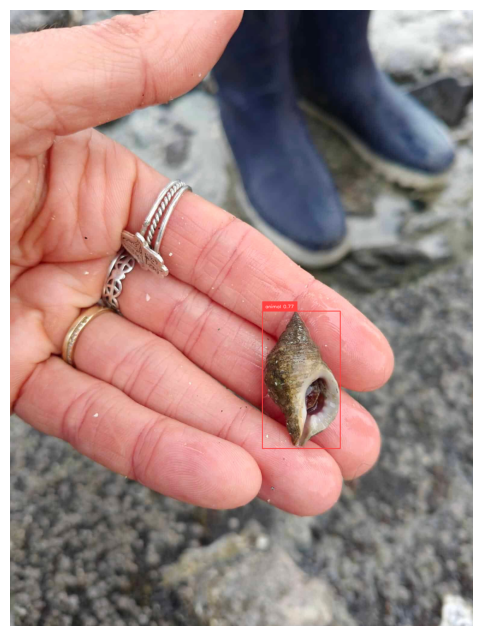

In [27]:
plot(
    image=cv2.imread(f"{IMG_PATH}/110297_Pourpre_petite_pierre_2088.jpg"),
    classes=base_model.ontology.classes(),
    detections=results
)

## Distillation et entraînement de YOLOv8 large

In [30]:
base_model.label(
    input_folder=f"{IMG_PATH}",
    output_folder=f"{DATA_PATH}/labeled-images"
)

Labeling ../dataset_biolit/images/110410_Vélelle_2090.jpg: 100%|██████████| 1599/1599 [24:19<00:00,  1.10it/s]                                    


Labeled dataset created - ready for distillation.


In [5]:
os.listdir(f"{DATA_PATH}/labeled-images/")

['images', 'annotations', 'data.yaml', 'train', 'valid']

In [6]:
# target_model = YOLOv8("yolov8l.pt")
target_model = YOLOv8("yolov8n.pt")

In [7]:
target_model.train(f"{DATA_PATH}/labeled-images/data.yaml", epochs=50)

Ultralytics 8.4.22 🚀 Python-3.12.9 torch-2.10.0+cu128 CPU (Intel Xeon Platinum 8259CL CPU @ 2.50GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_biolit/labeled-images/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

KeyboardInterrupt: 